<a href="https://colab.research.google.com/github/Siew-116/grass_segmentation_unet/blob/main/model2_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grass Segmentation (Attention U-Net + MobileNetv2)
Model 2

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

In [5]:
img_zip_path = "/content/drive/MyDrive/split_3.zip"

with zipfile.ZipFile(img_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [6]:
# Import library
import tensorflow as tf
import keras
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from tensorflow import data  as tf_data
from tensorflow import image as tf_image
from tensorflow import io    as tf_io
from keras import layers, Model
import keras.backend as K
import random

In [7]:
# Configuration
BASE_DIR        = "/content/dataset/split_3"
TRAIN_IMAGE_DIR = os.path.join(BASE_DIR, "train", "images")
TRAIN_MASK_DIR  = os.path.join(BASE_DIR, "train", "masks")
VAL_IMAGE_DIR   = os.path.join(BASE_DIR, "val",   "images")
VAL_MASK_DIR    = os.path.join(BASE_DIR, "val",   "masks")
TEST_IMAGE_DIR  = os.path.join(BASE_DIR, "test",  "images")
TEST_MASK_DIR   = os.path.join(BASE_DIR, "test",  "masks")

MODEL_DIR       = "/content/attention_unet/models"
LOG_DIR         = "/content/attention_unet/logs"
RESULT_DIR      = "/content/attention_unet/results"

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# ---- Model config ----
IMG_SIZE    = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE  = 32
EPOCHS      = 20
SEED        = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LR_P1 = 1e-4
LR_P2 = 1e-5

CLASS_NAMES = {
    0: "background",
    1: "grass_short",
    2: "grass_medium",
    3: "grass_long"
}

print(f"  Image size   : {IMG_SIZE}")
print(f"  Num classes  : {NUM_CLASSES}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Epochs       : {EPOCHS}")


Configuration ready
  Image size   : (256, 256)
  Num classes  : 4
  Batch size   : 32
  Epochs       : 20


# Preprocessing dataset

In [8]:
# Verify and match data
print("Verifying data...")
for name, img_dir, mask_dir in [
    ("Train", TRAIN_IMAGE_DIR, TRAIN_MASK_DIR),
    ("Val",   VAL_IMAGE_DIR,   VAL_MASK_DIR),
    ("Test",  TEST_IMAGE_DIR,  TEST_MASK_DIR),
]:
    n_img  = len(os.listdir(img_dir))
    n_mask = len(os.listdir(mask_dir))
    match  = "OK" if n_img == n_mask else "MISMATCH"
    print(f"  {name:<6} images: {n_img:>5}  masks: {n_mask:>5}  [{match}]")

Verifying data...
  Train  images:  4796  masks:  4796  [OK]
  Val    images:   600  masks:   600  [OK]
  Test   images:   600  masks:   600  [OK]


In [9]:
# Pair original image with mask
def get_path_pairs(image_dir, mask_dir):
    image_files = sorted(os.listdir(image_dir))
    img_paths   = []
    mask_paths  = []
    missing     = []

    for img_file in image_files:
        stem      = os.path.splitext(img_file)[0]
        mask_file = stem + ".png"
        img_path  = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir,  mask_file)

        if os.path.exists(mask_path):
            img_paths.append(img_path)
            mask_paths.append(mask_path)
        else:
            missing.append(img_file)

    print(f"  Pairs: {len(img_paths)}  Missing: {len(missing)}")
    return img_paths, mask_paths

print("Building path pairs...")
train_img_paths,  train_mask_paths  = get_path_pairs(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
val_img_paths,    val_mask_paths    = get_path_pairs(VAL_IMAGE_DIR,   VAL_MASK_DIR)
test_img_paths,   test_mask_paths   = get_path_pairs(TEST_IMAGE_DIR,  TEST_MASK_DIR)

print(f"\nTrain : {len(train_img_paths)}")
print(f"Val   : {len(val_img_paths)}")
print(f"Test  : {len(test_img_paths)}")

Building path pairs...
  Pairs: 4796  Missing: 0
  Pairs: 600  Missing: 0
  Pairs: 600  Missing: 0

Train : 4796
Val   : 600
Test  : 600


In [10]:
import cv2

print("Computing class weights from training masks...")
counts = np.zeros(NUM_CLASSES, dtype=np.int64)

for mask_path in train_mask_paths:
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        continue
    for c in range(NUM_CLASSES):
        counts[c] += np.sum(m == c)   # just one integer per class, no list

total         = counts.sum()
freqs         = (counts / total).astype(np.float32)
weights = 1.0 / np.sqrt(freqs)
weights = weights / weights.mean()

class_weights = {i: float(weights[i]) for i in range(4)}

print(f"  Frequencies   : {np.round(freqs, 4)}")
print(f"  Class Weights: {class_weights}")

Computing class weights from training masks...
  Frequencies   : [0.9315 0.0377 0.0177 0.0131]
  Class Weights: {0: 0.18471448123455048, 1: 0.9182360768318176, 2: 1.3416492938995361, 3: 1.555400013923645}


In [11]:
# Load data
def load_img_mask(img_path, mask_path):
    # Load image
    img = tf_io.read_file(img_path)
    img = tf_io.decode_jpeg(img, channels=3)
    img = tf_image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    # Load mask
    mask = tf_io.read_file(mask_path)
    mask = tf_io.decode_png(mask, channels=1)
    mask = tf_image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask, tf.uint8)

    return img, mask

In [12]:
# Augmentation
def augment_fn(img, mask):
    # Horizontal flip
    flip = tf.random.uniform([]) > 0.5
    img  = tf.cond(flip, lambda: tf_image.flip_left_right(img),  lambda: img)
    mask = tf.cond(flip, lambda: tf_image.flip_left_right(mask), lambda: mask)

    # Vertical flip
    flip = tf.random.uniform([]) > 0.5
    img  = tf.cond(flip, lambda: tf_image.flip_up_down(img),  lambda: img)
    mask = tf.cond(flip, lambda: tf_image.flip_up_down(mask), lambda: mask)

    # Random brightness — image only, never mask
    img = tf_image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random contrast
    img = tf_image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random saturation
    img = tf_image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random HUE
    img = tf_image.random_hue(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

In [13]:
# Get dataset
def get_dataset(img_paths, mask_paths, batch_size, augment=False, shuffle=True):
    dataset = tf_data.Dataset.from_tensor_slices((img_paths, mask_paths))
    dataset = dataset.map(load_img_mask, num_parallel_calls=tf_data.AUTOTUNE)

    if augment:
        dataset = dataset.map(augment_fn, num_parallel_calls=tf_data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)
        dataset = dataset.repeat() # only apply .repeat() to train data

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf_data.AUTOTUNE)
    return dataset


train_dataset = get_dataset(train_img_paths, train_mask_paths, BATCH_SIZE, augment=True,  shuffle=True)
val_dataset   = get_dataset(val_img_paths,   val_mask_paths,   BATCH_SIZE, augment=False, shuffle=False)
test_dataset  = get_dataset(test_img_paths,  test_mask_paths,  BATCH_SIZE, augment=False, shuffle=False)

#print(f"Train batches : {len(train_dataset)}") # infinite
print(f"Val batches   : {len(val_dataset)}")
print(f"Test batches  : {len(test_dataset)}")

Val batches   : 19
Test batches  : 19


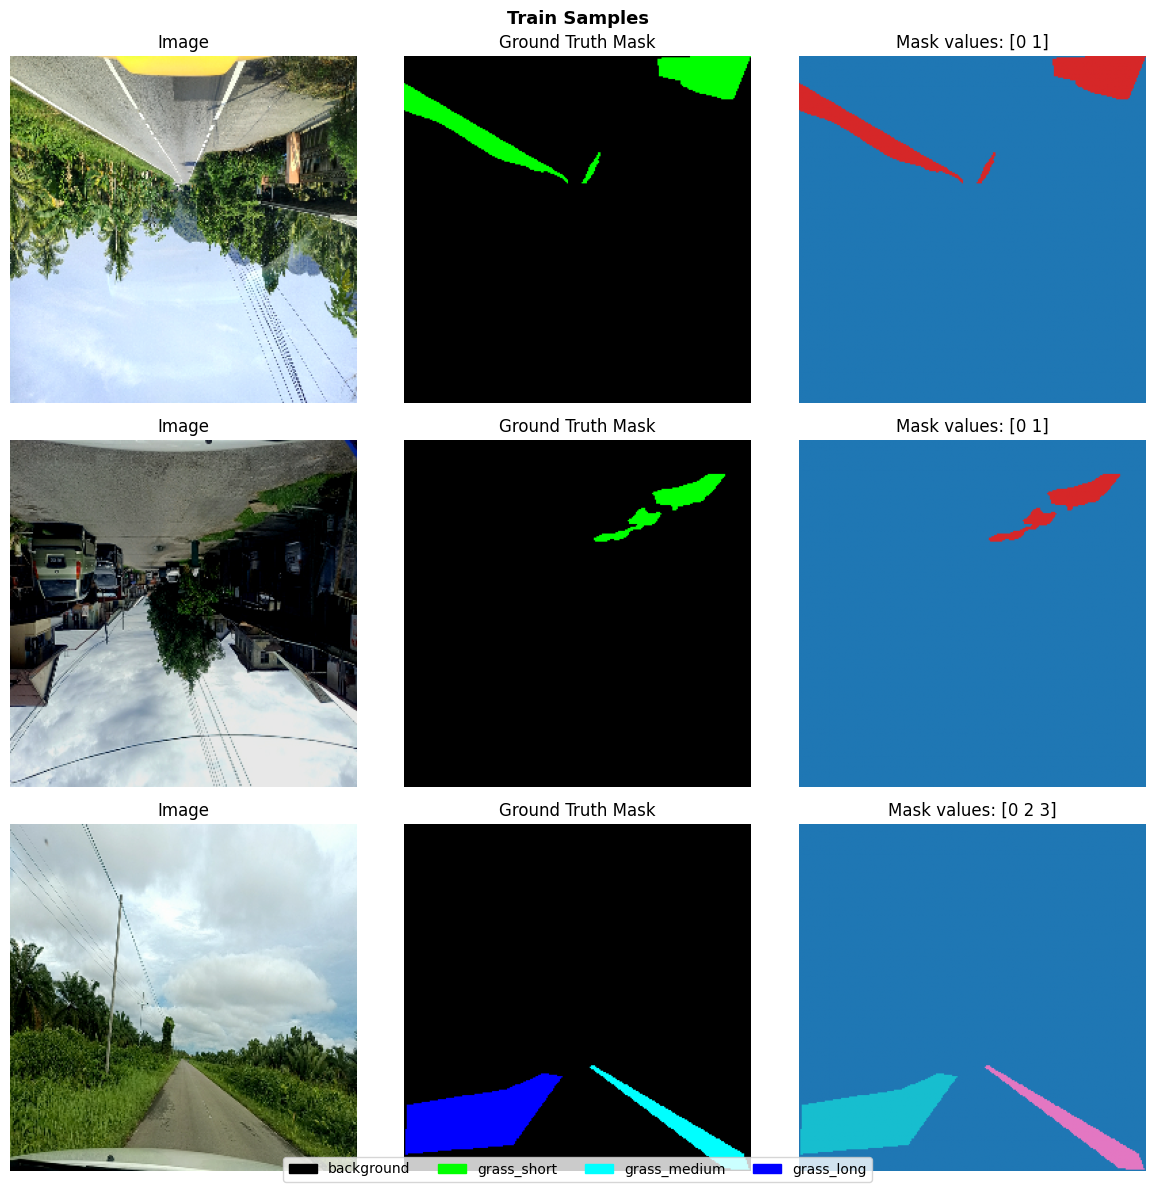

In [14]:
# Visualize samples
CLASS_COLORS = {
    0: [0,   0,   0],    # background  black
    1: [0,   255, 0],    # grass_short green
    2: [0,   255, 255],  # grass_medium yellow
    3: [0,   0,   255],  # grass_long  red
}

def mask_to_rgb(mask):
    mask  = np.squeeze(mask.numpy())
    rgb   = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb

def show_samples(dataset, n=3, title="Samples"):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for images, masks in dataset.take(1):
        for i in range(min(n, len(images))):
            axes[i][0].imshow(images[i].numpy())
            axes[i][0].set_title("Image")
            axes[i][0].axis("off")

            axes[i][1].imshow(mask_to_rgb(masks[i]))
            axes[i][1].set_title("Ground Truth Mask")
            axes[i][1].axis("off")

            # Show mask raw values
            unique = np.unique(masks[i].numpy())
            axes[i][2].imshow(masks[i].numpy().squeeze(), cmap="tab10", vmin=0, vmax=3)
            axes[i][2].set_title(f"Mask values: {unique}")
            axes[i][2].axis("off")

    # Legend
    patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[k])
               for k, c in CLASS_COLORS.items()]
    fig.legend(handles=patches, loc="lower center", ncol=4)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "sample_images.png"), dpi=150)
    plt.show()

show_samples(train_dataset, n=3, title="Train Samples")

In [15]:
# Build model

In [16]:
# Attention gate
def attention_gate(x, g, filters):
    """
    x : encoder feature map  (skip connection)
    g : decoder gating signal (upsampled decoder output)
    """
    # Compress both to same filter size
    theta_x = layers.Conv2D(filters, 1, padding="same")(x)  # encoder path
    phi_g   = layers.Conv2D(filters, 1, padding="same")(g)  # decoder path

    # Add and activate
    add     = layers.Add()([theta_x, phi_g])
    relu    = layers.Activation("relu")(add)

    # Attention coefficient (importance of each spatial location)
    psi     = layers.Conv2D(1, 1, padding="same")(relu)
    sigmoid = layers.Activation("sigmoid")(psi)

    # Apply attention to encoder features
    attended = layers.Multiply()([x, sigmoid])
    return attended

In [17]:
# BUILD MODEL
def build_attention_unet_mobilenetv2(img_size, num_classes):

    # ---- ENCODER: MobileNetV2 pretrained on ImageNet ----
    base_model = tf.keras.applications.MobileNetV2(
        input_shape = img_size + (3,),
        include_top = False,
        weights     = "imagenet"    # pretrained weights
    )

    # Freeze encoder
    base_model.trainable = False

    # Skip connection layers from MobileNetV2
    skip_layer_names = [
        "block_1_expand_relu",    # 64x64
        "block_3_expand_relu",    # 32x32
        "block_6_expand_relu",    # 16x16
        "block_13_expand_relu",   # 8x8
        "block_16_project",       # 4x4  (bottleneck)
    ]

    # Extract skip connection outputs
    skip_outputs = [base_model.get_layer(name).output for name in skip_layer_names]
    encoder      = Model(inputs=base_model.input, outputs=skip_outputs, name="mobilenetv2_encoder")

    # ---- DECODER with attention gates ----
    inputs  = layers.Input(shape=img_size + (3,), name="input_image")
    skips   = encoder(inputs)
    x       = skips[-1]           # start from bottleneck
    skips_reversed = list(reversed(skips[:-1]))

    # Match decoder size to encoder
    decoder_filters = [320, 192, 144, 96]

    for filters, skip in zip(decoder_filters, skips_reversed):
        # Upsample
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # attention gate on skip connection
        skip_attended = attention_gate(
            x=skip,   # encoder feature map
            g=x,      # decoder gating signal
            filters=filters // 2
        )
        # Concatenate attended skip instead of raw skip
        x = layers.Concatenate()([x, skip_attended])

        # Refine
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(0.1)(x)

        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(0.1)(x)

    # Final upsample to original size
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Output layer — softmax over num_classes
    outputs = layers.Conv2D(num_classes, 1, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="attention_unet_mobilenetv2")
    return model, base_model


model, base_model = build_attention_unet_mobilenetv2(IMG_SIZE, NUM_CLASSES)
model.summary()

/tmp/ipykernel_3078/4196438957.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "attention_unet_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 128, 128, │  1,841,984 │ input_image[0][0] │
│ (Functional)        │ 96), (None, 64,   │            │                   │
│                     │ 64, 144), (None,  │            │                   │
│                     │ 32, 32, 192),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 576), (None, 8,   │            │                   │
│                     │ 8, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    921,920 │ mobilenetv2_enco… │
│ (Conv2DTranspose)   │ 320)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │      1,280 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 320)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 320)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │     92,320 │ mobilenetv2_enco… │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     51,360 │ re_lu[0][0]       │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ conv2d[0][0],     │
│                     │ 160)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (Activation)        │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16, 1) │        161 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16, 1) │          0 │ conv2d_2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ mobilenetv2_enco… │
│                     │ 576)              │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ re_lu[0][0],      │
│ (Concatenate)       │ 896)              │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │  2,580,800 │ concatenate[0][0] │
│                     │ 320)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,280 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 320)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,246,432 (35.27 MB)

 Trainable params: 7,399,872 (28.23 MB)

 Non-trainable params: 1,846,560 (7.04 MB)

# Metrics - IoU

In [18]:
class MeanIoUExcludeBackground(tf.keras.metrics.Metric):
    def __init__(self, num_classes=4, name="mean_iou_no_bg", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.iou = tf.keras.metrics.MeanIoU(num_classes=num_classes)

    def update_state(self, y_true, y_pred, sample_weight=None):
        if y_true.shape[-1] == self.num_classes:
            yt = tf.argmax(y_true, axis=-1)
        else:
            yt = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
        yp = tf.argmax(y_pred, axis=-1)
        self.iou.update_state(yt, yp, sample_weight=sample_weight)

    def result(self):
        cm   = tf.cast(self.iou.total_cm, tf.float32)
        ious = []
        for c in range(1, self.num_classes):
            tp    = cm[c, c]
            fp    = tf.reduce_sum(cm[:, c]) - tp
            fn    = tf.reduce_sum(cm[c, :]) - tp
            denom = tp + fp + fn
            iou_c = tf.where(denom > 0, tp / denom, 0.0)
            ious.append(iou_c)
        return tf.reduce_mean(tf.stack(ious))

    def reset_states(self):
        self.iou.reset_states()

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config

    @classmethod
    def from_config(cls, config):
        # force num_classes=4 if missing from old saved config
        config.setdefault("num_classes", 4)
        return cls(**config)

# Loss function

In [19]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

def total_loss(y_true, y_pred):
    y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    weights_map = tf.gather(
        tf.constant([class_weights[i] for i in range(4)], dtype=tf.float32),
        y_true_flat
    )
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        tf.reshape(y_true, [-1]),   # flat 1D
        tf.reshape(y_pred, [-1, NUM_CLASSES])
    )
    return tf.reduce_mean(loss * weights_map)

In [ ]:
# ---- Phase 1: Initial Training ----
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P1),
    loss=total_loss,
    metrics=[
        "accuracy",
        MeanIoUExcludeBackground(NUM_CLASSES, name="mean_iou_no_bg")
    ]
)

STEPS_PER_EPOCH  = len(train_img_paths) // BATCH_SIZE
VALIDATION_STEPS = len(val_img_paths)   // BATCH_SIZE

checkpoint_path = os.path.join(MODEL_DIR, "attention_unet_1.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = checkpoint_path,
        monitor        = "val_mean_iou_no_bg",
        mode           = "max",
        save_best_only = True,
        verbose        = 1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_mean_iou_no_bg",
        mode                 = "max",
        patience             = 12,
        verbose              = 1,
        restore_best_weights = True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mean_iou_no_bg",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir = LOG_DIR
    )
]

# Run training
history = model.fit(
    train_dataset,
    epochs           = EPOCHS,
    steps_per_epoch  = STEPS_PER_EPOCH,
    validation_data  = val_dataset,
    validation_steps = VALIDATION_STEPS,
    callbacks        = callbacks
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.5183 - loss: 0.3047 - mean_iou_no_bg: 0.0368
Epoch 1: val_mean_iou_no_bg improved from -inf to 0.05437, saving model to /content/attention_unet/models/attention_unet_1.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 231s 857ms/step - accuracy: 0.5198 - loss: 0.3043 - mean_iou_no_bg: 0.0369 - val_accuracy: 0.7074 - val_loss: 0.3143 - val_mean_iou_no_bg: 0.0544 - learning_rate: 1.0000e-04
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9172 - loss: 0.1700 - mean_iou_no_bg: 0.2002
Epoch 2: val_mean_iou_no_bg improved from 0.05437 to 0.23896, saving model to /content/attention_unet/models/attention_unet_1.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 111s 745ms/step - accuracy: 0.9172 - loss: 0.1700 - mean_iou_no_bg: 0.2003 - val_accuracy: 0.9237 - val_loss: 0.1980 - val_mean_iou_no_bg: 0.2390 - learning_rate: 1.0000e-04
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9210 - loss: 0.1450 - mean_iou_no_bg: 0

In [ ]:
# ---- Phase 2: Fine-tuning ----
# Unfreeze encoder, keep BN frozen
freeze_until = int(len(base_model.layers) * 0.75)
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= freeze_until)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Recompile with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P2),  # 10x lower than phase 1
    loss=total_loss,
    metrics=[
        "accuracy",
        MeanIoUExcludeBackground(NUM_CLASSES, name="mean_iou_no_bg")
    ]
)

# New checkpoint to prevent overwrite phase 1 best model
ft_checkpoint_path = os.path.join(MODEL_DIR, "attention_unet_2.keras")

ft_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = ft_checkpoint_path,
        monitor        = "val_mean_iou_no_bg",
        mode           = "max",
        save_best_only = True,
        verbose        = 1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_mean_iou_no_bg",
        mode                 = "max",
        patience             = 3,      # shorter patience for fine-tune
        verbose              = 1,
        restore_best_weights = True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mean_iou_no_bg",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# Continue training from where phase 1 stopped
ft_history = model.fit(
    train_dataset,
    epochs           = EPOCHS + 10,         # extra epochs on top
    initial_epoch    = EPOCHS,              # starts counting from epoch 20
    steps_per_epoch  = STEPS_PER_EPOCH,
    validation_data  = val_dataset,
    validation_steps = VALIDATION_STEPS,
    callbacks        = ft_callbacks
)

In [ ]:
def plot_history(history, path, ylim_loss=(0, 5.0), ylim_iou=(0, 0.2), ylim_acc=(0, 1.0)):
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    iou      = history.history["mean_iou_no_bg"]
    val_iou  = history.history["val_mean_iou_no_bg"]
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]

    epochs_total = range(1, len(loss) + 1)
    fig, axes    = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History", fontsize=13, fontweight="bold")

    for ax, tr, va, title, ylim in zip(
        axes,
        [loss,     iou,        acc],
        [val_loss, val_iou,    val_acc],
        ["Loss",   "Mean IoU(No BG)", "Accuracy"],
        [ylim_loss, ylim_iou,  ylim_acc]
    ):
        ax.plot(epochs_total, tr, label="Train",      color="steelblue")
        ax.plot(epochs_total, va, label="Validation", color="darkorange")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylim(ylim)
        ax.legend()

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved : {path}")


# Phase 1
path = os.path.join(RESULT_DIR, "training_history_phase1.png")
plot_history(history, path)

# Phase 2
if ft_history and len(ft_history.history["loss"]) > 0:
    path = os.path.join(RESULT_DIR, "training_history_phase2.png")
    plot_history(ft_history, path)
else:
    print("Phase 2 did not improve, skipping ft_history plot.")

In [ ]:
# Load best model and evaluate
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# Check model exists before load
if os.path.exists(ft_checkpoint_path):
    load_path = ft_checkpoint_path
    print("Loading Phase 2 model")
else:
    load_path = checkpoint_path
    print("Loading Phase 1 model")

best_model = tf.keras.models.load_model(
    load_path,
    custom_objects={
        "MeanIoUExcludeBackground": MeanIoUExcludeBackground,
        "total_loss": total_loss
    }
)

results = best_model.evaluate(test_dataset, verbose=1)
print(f"\n  Test Loss     : {results[0]:.4f}")
print(f"  Test Accuracy : {results[1]:.4f}")
print(f"  Test Mean IoU : {results[2]:.4f}")

In [ ]:
print("===== PER CLASS IoU =====")

all_preds = []
all_masks = []

for images, masks in test_dataset:
    preds = best_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=-1)
    masks = masks.numpy().squeeze(axis=-1)
    all_preds.append(preds)
    all_masks.append(masks)

all_preds = np.concatenate(all_preds, axis=0)
all_masks = np.concatenate(all_masks, axis=0)

def compute_iou(preds, masks, class_id):
    pred_c       = (preds == class_id)
    mask_c       = (masks == class_id)
    intersection = np.logical_and(pred_c, mask_c).sum()
    union        = np.logical_or(pred_c,  mask_c).sum()
    if union == 0:
        return float("nan")
    return intersection / union

print(f"\n  {'Class':<5} {'Name':<15} {'IoU':>8}  Status")
print(f"  {'-'*45}")

iou_scores = {}
for class_id, name in CLASS_NAMES.items():
    iou = compute_iou(all_preds, all_masks, class_id)
    iou_scores[name] = iou
    if np.isnan(iou):
        status = "NOT PRESENT"
    elif iou >= 0.7:
        status = "GOOD"
    elif iou >= 0.5:
        status = "ACCEPTABLE"
    else:
        status = "POOR"
    print(f"  {class_id:<5} {name:<15} {iou:>8.4f}  {status}")

valid_ious = [v for v in iou_scores.values() if not np.isnan(v)]
mean_iou   = np.mean(valid_ious)
print(f"\n  Mean IoU (mIoU) : {mean_iou:.4f}")

In [ ]:
def show_predictions(dataset, model, n=20):
    fig, axes = plt.subplots(n, 4, figsize=(32, n * 4))
    fig.suptitle("Test Predictions", fontsize=13, fontweight="bold")

    for ax, title in zip(axes[0], ["Input", "Ground Truth", "Prediction", "Overlay"]):
        ax.set_title(title, fontsize=11, fontweight="bold")

    count = 0
    for images, masks in dataset:
        if count >= n:
            break

        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=-1)   # (B, 256, 256)

        for i in range(len(images)):
            if count >= n:
                break

            img     = images[i].numpy()       # (256, 256, 3)
            gt_mask = masks[i].numpy()        # (256, 256, 4) one-hot  OR  (256, 256, 1) sparse

            # Convert ground truth to sparse (256, 256)
            if gt_mask.ndim == 3 and gt_mask.shape[-1] == NUM_CLASSES:
                gt_mask = np.argmax(gt_mask, axis=-1)   # one-hot → sparse
            else:
                gt_mask = np.squeeze(gt_mask)           # (256,256,1) → (256,256)

            pred_mask = preds[i]              # (256, 256)

            # Ground truth RGB
            gt_rgb = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
            for cid, color in CLASS_COLORS.items():
                gt_rgb[gt_mask == cid] = color

            # Prediction RGB
            pred_rgb = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
            for cid, color in CLASS_COLORS.items():
                pred_rgb[pred_mask == cid] = color

            # Overlay prediction on original image
            overlay = (img * 255).astype(np.uint8).copy()
            alpha   = 0.4
            for cid, color in CLASS_COLORS.items():
                if cid == 0:
                    continue  # skip background
                region          = pred_mask == cid
                overlay[region] = (
                    overlay[region] * (1 - alpha) +
                    np.array(color) * alpha
                ).astype(np.uint8)

            axes[count][0].imshow(img);      axes[count][0].axis("off")
            axes[count][1].imshow(gt_rgb);   axes[count][1].axis("off")
            axes[count][2].imshow(pred_rgb); axes[count][2].axis("off")
            axes[count][3].imshow(overlay);  axes[count][3].axis("off")

            # Row label with image index
            axes[count][0].set_ylabel(f"Sample {count+1}", fontsize=9)

            count += 1

    patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[k])
               for k, c in CLASS_COLORS.items()]
    fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=10)
    plt.tight_layout()
    path = os.path.join(RESULT_DIR, "test_predictions.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved : {path}")

show_predictions(test_dataset, best_model, n=20)

In [ ]:
report = {
    "generated_at" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model"        : "Attention UNet with MobileNetV2 encoder",
    "config"       : {
        "img_size"   : list(IMG_SIZE),
        "num_classes": NUM_CLASSES,
        "batch_size" : BATCH_SIZE,
        "epochs"     : EPOCHS,
        "loss"       : "Combined CCE, Focal loss, Tversky loss",
        "optimizer"  : "Adam"
    },
    "dataset"      : {
        "train" : len(train_img_paths),
        "val"   : len(val_img_paths),
        "test"  : len(test_img_paths)
    },
    "test_results" : {
        "loss"     : round(float(results[0]), 4),
        "accuracy" : round(float(results[1]), 4),
        "mean_iou_no_bg" : round(float(mean_iou),   4)
    },
    "per_class_iou": {
        name: round(float(iou), 4) if not np.isnan(iou) else None
        for name, iou in iou_scores.items()
    }
}

report_path = os.path.join(RESULT_DIR, "evaluation_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=4)

print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)
print(f"\n  Model    : {checkpoint_path}")
print(f"  Report   : {report_path}")
print(f"  Plots    : {RESULT_DIR}")
print(f"\n  Test Loss     : {results[0]:.4f}")
print(f"  Test Accuracy : {results[1]:.4f}")
print(f"  Test Mean IoU : {mean_iou:.4f}")
print(f"\n  Per Class IoU:")
for name, iou in iou_scores.items():
    if not np.isnan(iou):
        print(f"    {name:<15} : {iou:.4f}")

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Flatten all predictions and masks
y_true_flat = all_masks.flatten()
y_pred_flat = all_preds.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2, 3])

# Normalized version (shows % instead of raw counts)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix", fontsize=13, fontweight="bold")

class_labels = list(CLASS_NAMES.values())

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Raw Counts")
axes[0].set_xticklabels(class_labels, rotation=15)

# Normalized
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=class_labels)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Normalized (per true class)")
axes[1].set_xticklabels(class_labels, rotation=15)

plt.tight_layout()
path = os.path.join(RESULT_DIR, "confusion_matrix.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved : {path}")

In [ ]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive("/content/attention_unet", 'zip', "/content/attention_unet")

# Download
files.download("/content/attention_unet.zip")